In [1]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_Larsson

In [2]:
dim = 1
v0 = 1
M = 1
p = 4

def infPotFunc(phi):
    x = phi / M
    return v0 * (1 - x ** p) ** 2

def infPotDerivFunc(phi):
    x = phi / M
    return -2 * p * v0 / M * (1 - x ** p) * x ** (p - 1)

def infPotDeriv2Func(phi):
    x = phi / M
    return 2 * p * v0 / M / M * ((2 * p - 1) * x ** p - p + 1) * x ** (p - 2)

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

nGrid = 256
upperBound = (M * M / 2 / p / (p - 1)) ** (1 / (p - 2)) * M
lowerBound = -upperBound

In [3]:
fpFinDiff = InfAdjFPFiniteDiff_Larsson(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    nGrid,
    upperBound,
    lowerBound
)

In [4]:
fpFinDiff

array([[ 3334.06714447, -1667.50266869,     0.        , ...,
            0.        ,     0.        ,     0.        ],
       [-1667.50266869,  3334.43585149, -1667.67490753, ...,
            0.        ,     0.        ,     0.        ],
       [    0.        , -1667.67490753,  3334.79586144, ...,
            0.        ,     0.        ,     0.        ],
       ...,
       [    0.        ,     0.        ,     0.        , ...,
         3334.79586144, -1667.67490753,     0.        ],
       [    0.        ,     0.        ,     0.        , ...,
        -1667.67490753,  3334.43585149, -1667.50266869],
       [    0.        ,     0.        ,     0.        , ...,
            0.        , -1667.50266869,  3334.06714447]])

In [5]:
eigVals, eigVecs = np.linalg.eig(fpFinDiff)
eigVecsSort = eigVecs.T[np.argsort(eigVals)]
eigValsSort = np.sort(eigVals)

In [6]:
import matplotlib.pyplot as plt

In [7]:
nMode = np.arange(1, nGrid + 1)
eigValsFlat = [np.pi ** 2 * v0 / (24 * np.pi ** 2) / (upperBound - lowerBound) ** 2 * n ** 2 for n in nMode]

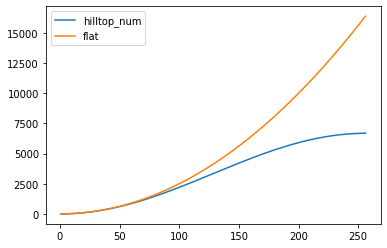

In [8]:
ax = plt.gca()
plt.plot(nMode, eigValsSort, label = "hilltop_num")
plt.plot(nMode, eigValsFlat, label = "flat")
plt.legend()
plt.show()

固有値は、flat potentialの場合の値とほぼ一致する

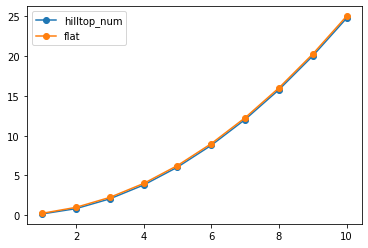

In [9]:
ax = plt.gca()
plt.plot(np.arange(1, 11), eigValsSort[:10], marker='o', label = "hilltop_num")
plt.plot(np.arange(1, 11), eigValsFlat[:10], marker='o', label = "flat")
plt.legend()
plt.show()

考えている$\phi$の領域をちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [10]:
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))
sigma = (upperBound - lowerBound) / 6.0
trialVec = np.exp(- 0.5 * ((grids - 0.5 * (upperBound + lowerBound)) / sigma) ** 2)
trialVec /= np.linalg.norm(trialVec)

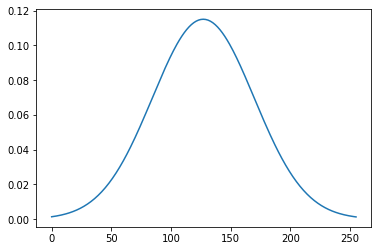

In [11]:
ax = plt.gca()
plt.plot(trialVec)
plt.show()

In [12]:
contriEachEigVec = [np.dot(trialVec, ev) ** 2 for ev in eigVecsSort]

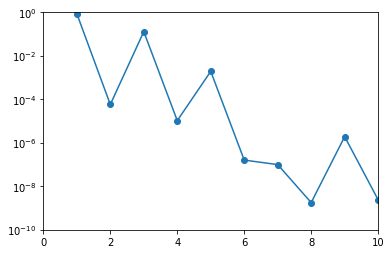

In [13]:
# 各固有ベクトルの寄与度
ax = plt.gca()
plt.plot(nMode, contriEachEigVec, marker='o')
plt.yscale('log')
ax.set_xlim(0, 10)
ax.set_ylim(1e-10, 1)
plt.show()

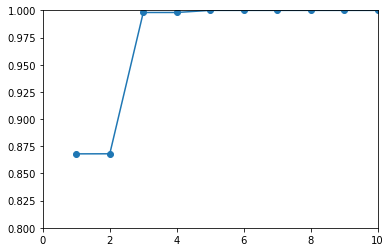

In [14]:
# 各固有ベクトルの寄与度（累積）
ax = plt.gca()
plt.plot(nMode, np.cumsum(contriEachEigVec), marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(0.8, 1)
plt.show()

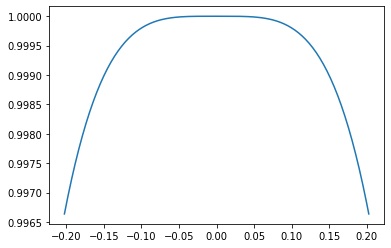

In [15]:
# ポテンシャル
ax = plt.gca()
grid = np.linspace(lowerBound, upperBound, nGrid + 2, endpoint=True)[1:-1]
plt.plot(grid, infPotFunc(grid))
plt.show()

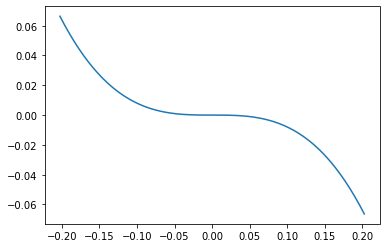

In [16]:
# ポテンシャル1次微分
ax = plt.gca()
grid = np.linspace(lowerBound, upperBound, nGrid + 2, endpoint=True)[1:-1]
plt.plot(grid, infPotDerivFunc(grid))
plt.show()

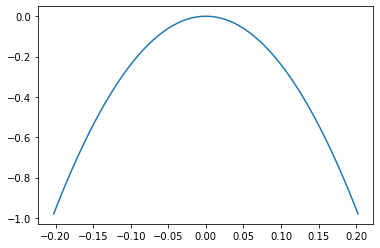

In [17]:
# ポテンシャル2次微分
ax = plt.gca()
grid = np.linspace(lowerBound, upperBound, nGrid + 2, endpoint=True)[1:-1]
plt.plot(grid, infPotDeriv2Func(grid))
plt.show()

結局、ポテンシャルはflatとほぼ同じ（原点付近はほぼflatで、slow roll parameter $\eta=1$となる近辺で急激に落ち込む）

　→固有値がflatの場合とほぼ一緒になるのは当然では？